### *credits*

Original_code:https://docs.pytorch.org/tutorials/intermediate/spatial_transformer_tutorial.html

Spatial Trasnformer networks are a generalization of differentiable attention to any spatial transformation.
Spatial transformer networks (STN) allow a neural network to learn hwo to perform spatial transformations on the input image in order to enhance the geometric invariance of the model. For example, it can crop a region of interest, scaler and correct the orientation of an image. It can be a unseful mechanism because CNNs are not invariant to rotation and scale and more general affine transformations.

### One of the best stuff about STN is the ability to simply plug it into any existing CNN with very little modification

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

plt.ion() ## intercative mode

## Loading the data

We will be loading the MNIST dataset. Using a standard CNN augmented with a STN

In [3]:
from six.moves import urllib
opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training dataset
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='.', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])), batch_size=64, shuffle=True, num_workers=4)
# Test dataset
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root='.', train=False, transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=64, shuffle=True, num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## The model

The model is basically :
Input image -> Spatial Transf. Net -> Normal CNN classifier -> Digit classes 0-9


Ovrall flow:

Input:
    
    1 x 28 x 28 image (typical MNIST image)

STN:

    localization CNN -> predict affine matrix theta -> generate grid -> sample trasnsformed image

Classifier:

    conv1 -> pool + ReLU -> conv2 + dropout -> pool + ReLU -> flatten -> fc1 -> dropout -> fc2 -> log_softmax

Output:

    probability over ten digit classes

### Localization netwrok does not classify., It predicts how to transform the image and Classifier does not know about transformations. It receives the transfomred image and classifies it.

Theta =
    
    [ a b tx
    c d ty ]

computes coordinate mappings :

Output pixel (x, y) -> Input coordinate (2.3 , 4.7)

so it prodices a map of coordinates, This coordinate map is the grid.

In [12]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

        # Spatial transformer localization-network
        self.localization = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=7),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True),
            nn.Conv2d(8, 10, kernel_size=5),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True)
        )

        # Regressor for the 3 * 2 affine matrix
        self.fc_loc = nn.Sequential(
            nn.Linear(10 * 3 * 3, 32),
            nn.ReLU(True),
            nn.Linear(32, 3 * 2)
        )

        # Initialize the weights/bias with identity transformation
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))

    # Spatial transformer network forward function
    def stn(self, x):
        xs = self.localization(x)
        xs = xs.view(-1, 10 * 3 * 3)
        theta = self.fc_loc(xs)
        theta = theta.view(-1, 2, 3)

        grid = F.affine_grid(theta, x.size())
        x = F.grid_sample(x, grid)

        return x

    def forward(self, x):
        # transform the input
        x = self.stn(x)

        # Perform the usual forward pass
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


model = Net().to(device)

## Training the model

In [13]:
optimizer = optim.SGD(model.parameters(), lr=0.01)


def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 500 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
#
# A simple test procedure to measure the STN performances on MNIST.
#


def test():
    with torch.no_grad():
        model.eval()
        test_loss = 0
        correct = 0
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # sum up batch loss
            test_loss += F.nll_loss(output, target, size_average=False).item()
            # get the index of the max log-probability
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()

        test_loss /= len(test_loader.dataset)
        print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'
              .format(test_loss, correct, len(test_loader.dataset),
                      100. * correct / len(test_loader.dataset)))

## Visualizing the STN results

/tmp/ipykernel_943/640561164.py:38: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  grid = F.affine_grid(theta, x.size())
/tmp/ipykernel_943/640561164.py:39: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  x = F.grid_sample(x, grid)


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.317335
Train Epoch: 1 [32000/60000 (53%)]	Loss: 1.152963


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3178: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Average loss: 0.4153, Accuracy: 8732/10000 (87%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.647680
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.287091

Test set: Average loss: 0.1168, Accuracy: 9657/10000 (97%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.417062
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.284271

Test set: Average loss: 0.0986, Accuracy: 9681/10000 (97%)

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.123839
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.458224

Test set: Average loss: 0.1230, Accuracy: 9675/10000 (97%)

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.212567
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.116887

Test set: Average loss: 0.0706, Accuracy: 9788/10000 (98%)

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.094605
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.232700

Test set: Average loss: 0.0634, Accuracy: 9812/10000 (98%)

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.179278
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.174042

Test set: Average loss: 0.0557, Accuracy: 9824/10000 (98%)

Tra

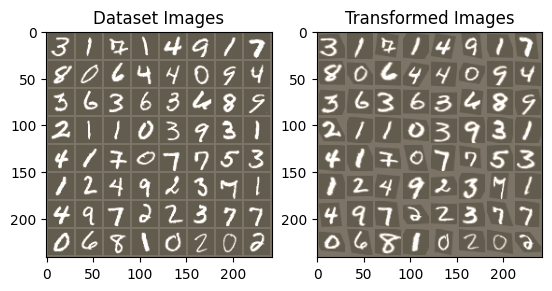

In [14]:
def convert_image_np(inp):
    """Convert a Tensor to numpy image."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    return inp

# We want to visualize the output of the spatial transformers layer
# after the training, we visualize a batch of input images and
# the corresponding transformed batch using STN.


def visualize_stn():
    with torch.no_grad():
        # Get a batch of training data
        data = next(iter(test_loader))[0].to(device)

        input_tensor = data.cpu()
        transformed_input_tensor = model.stn(data).cpu()

        in_grid = convert_image_np(
            torchvision.utils.make_grid(input_tensor))

        out_grid = convert_image_np(
            torchvision.utils.make_grid(transformed_input_tensor))

        # Plot the results side-by-side
        f, axarr = plt.subplots(1, 2)
        axarr[0].imshow(in_grid)
        axarr[0].set_title('Dataset Images')

        axarr[1].imshow(out_grid)
        axarr[1].set_title('Transformed Images')

for epoch in range(1, 20 + 1):
    train(epoch)
    test()

# Visualize the STN transformation on some input batch
visualize_stn()

plt.ioff()
plt.show()